In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split

## Load dataset

In [4]:
orig_df = pd.read_excel('AirQualityUCI.xlsx')
orig_df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


<Axes: >

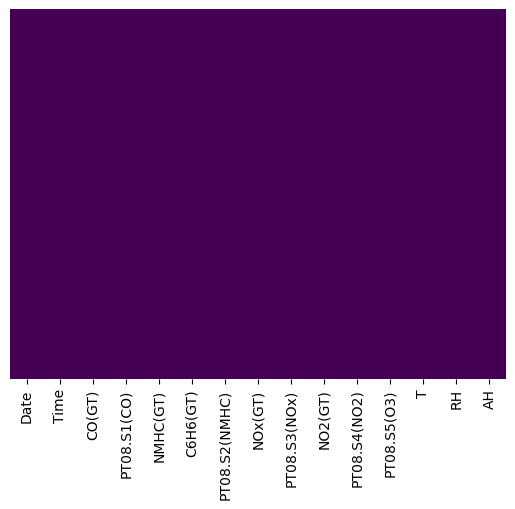

In [5]:
# Plot heatmap to visualize locations of missing values
sns.heatmap(orig_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

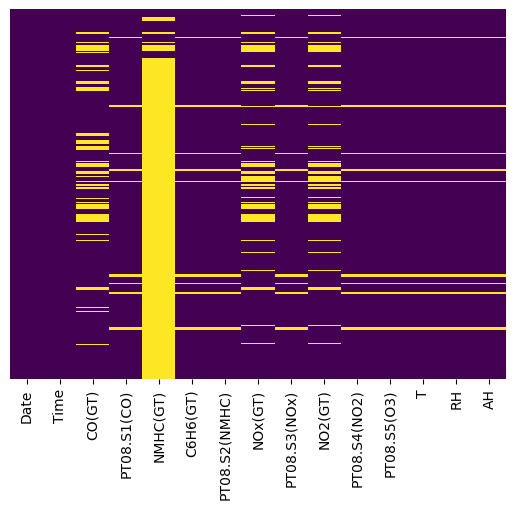

In [6]:
df = orig_df.copy()
df.replace(-200, np.nan, inplace=True)
# Plot heatmap to visualize locations of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

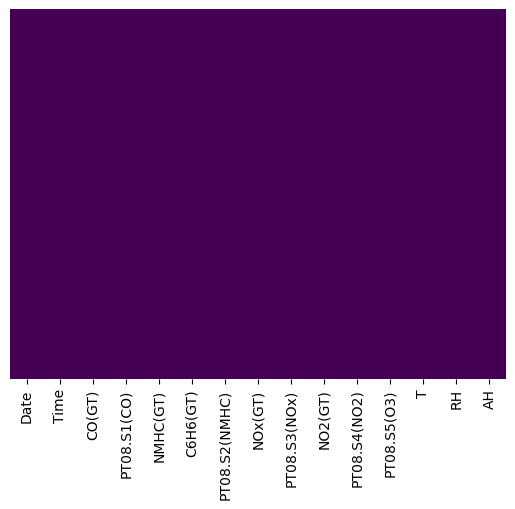

In [7]:
df = df.dropna().copy()
# Plot heatmap to visualize locations of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [8]:
df.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

In [9]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [10]:
df = df.rename(columns={'CO(GT)': 'CO',
                       'PT08.S1(CO)': 'PT08_S1',
                        'NMHC(GT)': 'NMHC',
                        'C6H6(GT)': 'C6H6',
                        'PT08.S2(NMHC)': 'PT08_S2',
                        'NOx(GT)': 'NOx',
                        'PT08.S3(NOx)': 'PT08_S3',
                        'NO2(GT)': 'NO2',
                        'PT08.S4(NO2)': 'PT08_S4',
                        'PT08.S5(O3)': 'PT08_S5'
})

In [11]:
# Finding numerical variables
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_df = df[num_features]
num_df.columns

Index(['CO', 'PT08_S1', 'NMHC', 'C6H6', 'PT08_S2', 'NOx', 'PT08_S3', 'NO2',
       'PT08_S4', 'PT08_S5', 'T', 'RH', 'AH'],
      dtype='object')

## Scaling

In [12]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

## Performance Evaluation

In [13]:
def compute_regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## Experiments

### Scale

In [14]:
num_df.columns

Index(['CO', 'PT08_S1', 'NMHC', 'C6H6', 'PT08_S2', 'NOx', 'PT08_S3', 'NO2',
       'PT08_S4', 'PT08_S5', 'T', 'RH', 'AH'],
      dtype='object')

In [15]:
num_df.head()

,CO,PT08_S1,NMHC,C6H6,PT08_S2,NOx,PT08_S3,NO2,PT08_S4,PT08_S5,T,RH,AH
0,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [16]:
selected_vars = ['CO','PT08_S1','T']
temp_df = num_df.copy()[selected_vars]
print(temp_df)

X1 = temp_df['CO']
X2 = temp_df['PT08_S1']
X3 = temp_df['T']

print("Before scaling")
from scipy.spatial.distance import euclidean, cityblock
print("Euclidean distance (X1,X2):", euclidean(X1, X2))
print("Manhattan distance (X1,X2):", cityblock(X1, X2))
print("Euclidean distance (X1,X3):", euclidean(X1, X3))
print("Manhattan distance (X1,X3):", cityblock(X1, X3))

       CO  PT08_S1       T
0     2.6  1360.00  13.600
1     2.0  1292.25  13.300
2     2.2  1402.00  11.900
3     2.2  1375.50  11.000
4     1.6  1272.25  11.150
...   ...      ...     ...
1226  4.4  1449.25  19.075
1227  3.1  1362.50  18.200
1228  3.0  1371.25  18.075
1229  3.1  1406.25  17.700
1230  3.5  1424.50  17.775

[827 rows x 3 columns]
Before scaling
Euclidean distance (X1,X2): 35346.53761138894
Manhattan distance (X1,X2): 996856.1000000001
Euclidean distance (X1,X3): 402.99598824795333
Manhattan distance (X1,X3): 10954.683340843512


In [17]:
selected_vars = ['CO','PT08_S1','T']
temp_df = num_df.copy()[selected_vars]

############################################
# Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)
print(temp_df_scaled)
############################################

X1_scaled = temp_df_scaled[:,0]  # 'CO'
X2_scaled = temp_df_scaled[:,1]  # 'PT08_S1'
X3_scaled = temp_df_scaled[:,2]  # 'T'

print("After scaling")
from scipy.spatial.distance import euclidean, cityblock
print("Euclidean distance (X1,X2):", euclidean(X1_scaled, X2_scaled))
print("Manhattan distance (X1,X2):", cityblock(X1_scaled, X2_scaled))
print("Euclidean distance (X1,X3):", euclidean(X1_scaled, X3_scaled))
print("Manhattan distance (X1,X3):", cityblock(X1_scaled, X3_scaled))

[[ 0.17494339  0.62999771 -0.4146817 ]
 [-0.25099827  0.34966893 -0.47688833]
 [-0.10901772  0.80378086 -0.76718595]
 ...
 [ 0.45890449  0.67654677  0.51323399]
 [ 0.52989477  0.82136606  0.43547569]
 [ 0.81385587  0.89687898  0.45102741]]
After scaling
Euclidean distance (X1,X2): 10.267915132826019
Manhattan distance (X1,X2): 235.93651904551325
Euclidean distance (X1,X3): 33.574609552558755
Manhattan distance (X1,X3): 741.7803893195523


In [18]:
# Question: Why manhattan distance is larger than euclidean distance?
# Answer and provide the reason: Because manhattan calculates from the difference of each dimension but euclidean calculates more like a pitagoras
#                                e.g. x, y => manhattan abs(x1 - x2) + abs(y1 - y2); euclidean sqrt((x1- x2)^2 + (y1 - y2)^2)

In [19]:
# Question: Scaling affects euclidean or manhattan more?  Why?
# Answer and provide the reason: Affects manhattan more than euclidean on scaling which refers to its calculation

### Covariance and Correlation

In [20]:
selected_vars = num_features
temp_df = num_df.copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)

temp_df_cov = np.cov(temp_df_scaled.T)
temp_df_corr = np.corrcoef(temp_df_scaled.T)

cov_df = pd.DataFrame(temp_df_cov, index=num_features, columns=num_features)
corr_df = pd.DataFrame(temp_df_corr, index=num_features, columns=num_features)

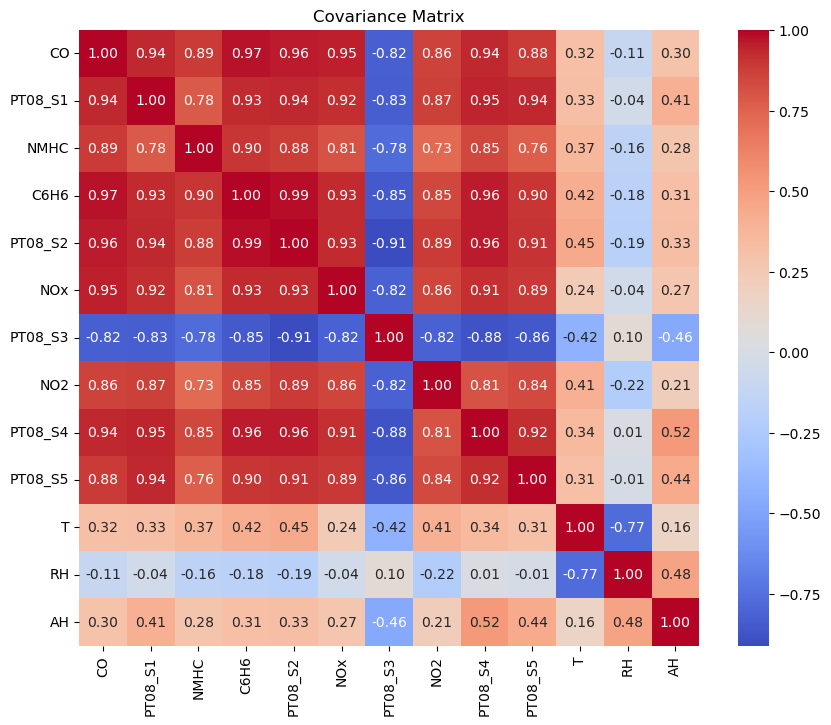

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(cov_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()

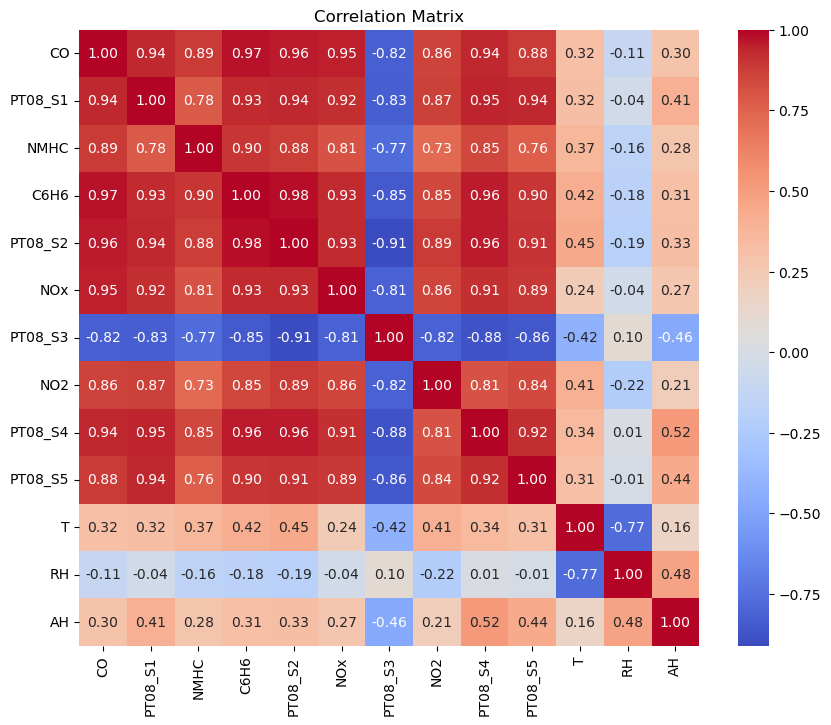

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

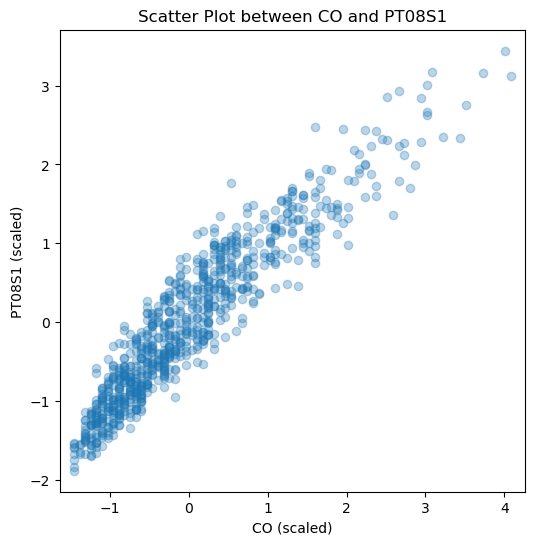

In [23]:
var1 = 'CO'
var2 = 'PT08S1'
var1_index = 0
var2_index = 1
plt.figure(figsize=(6,6))
plt.scatter(temp_df_scaled[:,var1_index], temp_df_scaled[:,var2_index], alpha=0.3)
plt.xlabel(var1 + " (scaled)")
plt.ylabel(var2 + " (scaled)")
plt.title("Scatter Plot between " + var1 + " and " + var2)
plt.axis("equal")
plt.show()

# Note that the scatter plot and heatmap shows that there are highly-correlated variables.
#           This suggests that variables are not independent or uncorrelated as they should be.

In [24]:
# Eigen-decomposition of Covariance matrix
temp_df = num_df.copy()

temp_df_mu = temp_df.mean(axis=0)
temp_df_cov = np.cov(temp_df, rowvar=False)  # Eigenvectors of the covariance matrix assume mean-centered data,
                                             # rowvar=False -> variables in columns
#temp_df_cov = np.cov(temp_df.T)             # If do not set rowvar to be false, can use transpose instead

# Eigen-decomposition
eigenvalues, eigenvectors = np.linalg.eigh(temp_df_cov)

# Sort eigenvalues in descending order
idx = np.argsort(eigenvalues)[::-1]  # Returns indices after sorting array in descending orde
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

Eigenvalues:
 [4.57511997e+05 1.91341584e+04 1.26985846e+04 7.27222599e+03
 3.59235902e+03 1.92634367e+03 7.29067316e+02 1.38362689e+02
 9.64398285e+01 3.44051563e+00 4.25257104e-01 4.98077682e-02
 1.78138835e-03]

Eigenvectors (columns):
 [[ 1.97329792e-03 -1.22729325e-03 -2.32485904e-03  8.04850821e-04
   2.24945087e-03  9.36791590e-04  5.25340948e-03  1.88181068e-03
   2.49819822e-03 -2.28419830e-02  1.66335917e-01  9.85366242e-01
  -2.84465107e-02]
 [ 3.43921737e-01  1.72760357e-01 -2.69633185e-01  4.43286116e-01
   4.52853209e-01 -6.00743100e-01 -1.10024480e-01 -6.69162218e-02
  -1.05566476e-02 -4.59034984e-04  1.36800208e-03 -1.43696778e-03
  -7.15576266e-05]
 [ 2.63950130e-01 -5.98239803e-01 -4.13334192e-01 -5.78811220e-01
   4.18745476e-03 -2.57408250e-01 -1.47587126e-02  7.13337157e-03
  -2.86778772e-03  1.39576276e-03 -3.98482696e-03 -7.64723246e-04
  -3.76832732e-05]
 [ 1.05630185e-02 -7.50988881e-03 -1.00761111e-02  3.70798204e-03
   6.80021398e-03  2.12562105e-02 -4.099671

### Distance

In [25]:
# Compute 4 distances without scaling
temp_df = num_df.copy()

# Create sets of 4 distance types between the first row and the next 200 rows
# The distance sets will be used to plot histograms next.
num_rows = 200
minkowski_p = 5
from scipy.spatial.distance import euclidean, cityblock, chebyshev, minkowski
euclidean_dists = [euclidean(temp_df.iloc[0], temp_df.iloc[i]) for i in range(1, num_rows)]
cityblock_dists = [cityblock(temp_df.iloc[0], temp_df.iloc[i]) for i in range(1, num_rows)]
minkowski_dists = [minkowski(temp_df.iloc[0], temp_df.iloc[i], minkowski_p) for i in range(1, num_rows)]
chebyshev_dists = [chebyshev(temp_df.iloc[0], temp_df.iloc[i]) for i in range(1, num_rows)]

In [26]:
# Compute 4 distances with scaling
temp_df = num_df.copy()

###################################################
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)
###################################################

# Create sets of 4 distance types between the first row and the next 200 rows
# The distance sets will be used to plot histograms next.
num_rows = 200
minkowski_p = 5
from scipy.spatial.distance import euclidean, cityblock, chebyshev, minkowski
euclidean_dists_scaled = [euclidean(temp_df_scaled[0], temp_df_scaled[i]) for i in range(1, num_rows)]
cityblock_dists_scaled = [cityblock(temp_df_scaled[0], temp_df_scaled[i]) for i in range(1, num_rows)]
minkowski_dists_scaled = [minkowski(temp_df_scaled[0], temp_df_scaled[i], minkowski_p) for i in range(1, num_rows)]
chebyshev_dists_scaled = [chebyshev(temp_df_scaled[0], temp_df_scaled[i]) for i in range(1, num_rows)]

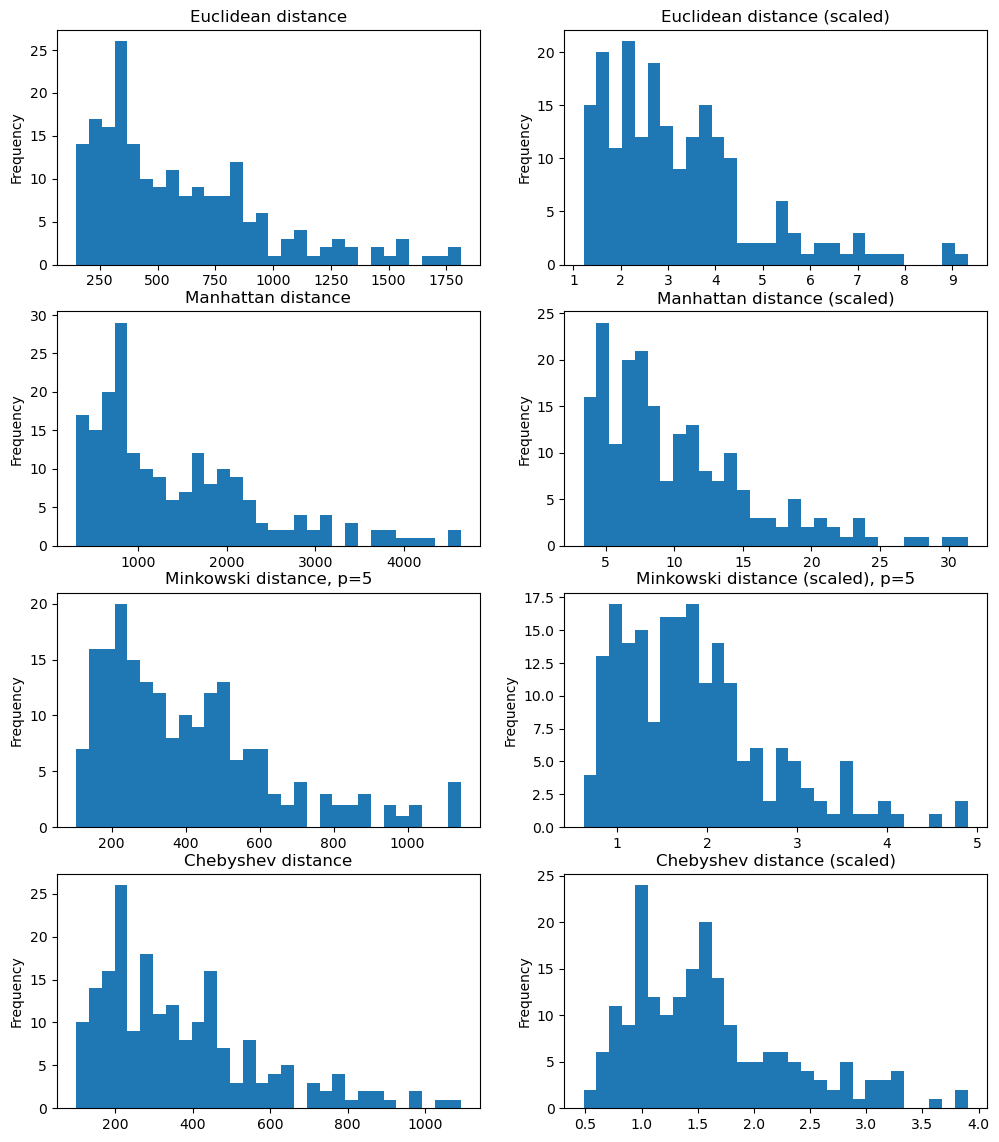

In [27]:
# Plot histograms of distances comparing (1) different distance types and (2) no-scaling vs. scaling

fig, axs = plt.subplots(4, 2, figsize=(12, 14))

axs[0,0].hist(euclidean_dists, bins=30)
axs[0,0].set_ylabel('Frequency')
axs[0,0].set_title('Euclidean distance')

axs[1,0].hist(cityblock_dists, bins=30)
axs[1,0].set_ylabel('Frequency')
axs[1,0].set_title('Manhattan distance')

axs[2,0].hist(minkowski_dists, bins=30)
axs[2,0].set_ylabel('Frequency')
axs[2,0].set_title('Minkowski distance, p='+str(minkowski_p))

axs[3,0].hist(chebyshev_dists, bins=30)
axs[3,0].set_ylabel('Frequency')
axs[3,0].set_title('Chebyshev distance')

axs[0,1].hist(euclidean_dists_scaled, bins=30)
axs[0,1].set_ylabel('Frequency')
axs[0,1].set_title('Euclidean distance (scaled)')

axs[1,1].hist(cityblock_dists_scaled, bins=30)
axs[1,1].set_ylabel('Frequency')
axs[1,1].set_title('Manhattan distance (scaled)')

axs[2,1].hist(minkowski_dists_scaled, bins=30)
axs[2,1].set_ylabel('Frequency')
axs[2,1].set_title('Minkowski distance (scaled), p='+str(minkowski_p))

axs[3,1].hist(chebyshev_dists_scaled, bins=30)
axs[3,1].set_ylabel('Frequency')
axs[3,1].set_title('Chebyshev distance (scaled)')

plt.show()

In [28]:
# Question: Compare the left and right histograms for the same distance type (without vs. with scaling),
#           do the distributions of the pairwise distances appear similar or noticeably different?
# Answer and Provide the reason: No such a huge differences the shape of histogram. It is still the same.

In [29]:
# Question: Compare the different distance types within the same column, 
#           which distance type tends to have larger distance values?  And which tends to have smaller values?
# Answer and Provide the reason: Manhattan > Euclidean > Minkowski > Chebyshev

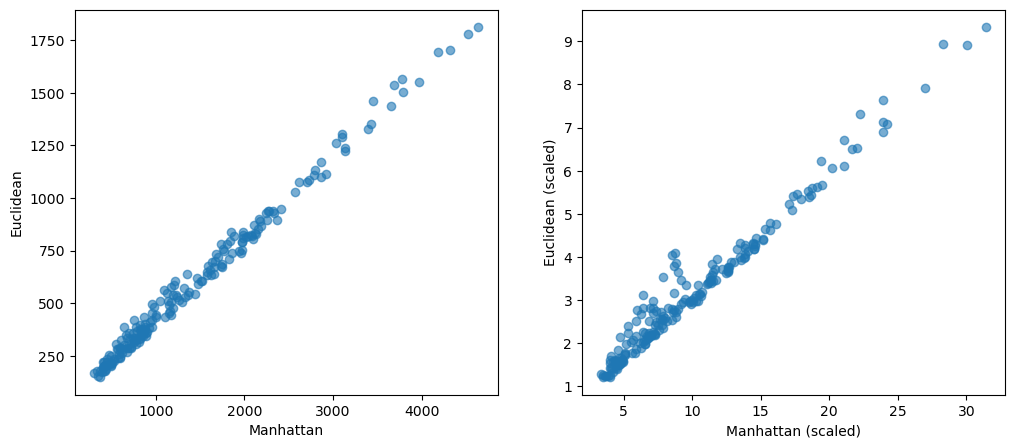

In [30]:
# Plot scatter plot to visualize the relationship between the values of the two distance types.

# Distance parameter list
# 'Euclidean'  # euclidean_dists, euclidean_dists_scaled
# 'Manhattan'  # cityblock_dists, cityblock_dists_scaled
# 'Minkowski'  # minkowski_dists, minkowski_dists_scaled
# 'Chebyshev'  # chebyshev_dists, chebyshev_dists_scaled

dist1 = 'Manhattan'  # You can change to other distance types using the parameter list above
dist2 = 'Euclidean'  # You can change to other distance types using the parameter list above

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(cityblock_dists, euclidean_dists, alpha=0.6)  # You can change to other distance types using the parameter list above
axs[0].set_xlabel(dist1)
axs[0].set_ylabel(dist2)
#axs[0].axis("equal")

axs[1].scatter(cityblock_dists_scaled, euclidean_dists_scaled, alpha=0.6)  # You can change to other distance types using the parameter list above
axs[1].set_xlabel(dist1+ " (scaled)")
axs[1].set_ylabel(dist2+ " (scaled)")
#axs[1].axis("equal")

plt.show()

In [31]:
# Compute mahalanobis and euclidean distances between each instance and variable mean

temp_df = num_df.copy()

from scipy.spatial.distance import euclidean, mahalanobis
temp_df_cov = np.cov(temp_df.T)
VI = np.linalg.inv(temp_df_cov)   # Find inverse of covariance and used as mahanobis parameters

num_rows = len(num_df)
temp_df_mu = temp_df.mean(axis=0)  # variable mean
temp_euclidean_dists = [euclidean(temp_df.iloc[i].values, temp_df_mu.values) for i in range(0, num_rows)]
temp_mahalanobis_dists = [mahalanobis(temp_df.iloc[i].values, temp_df_mu.values, VI) for i in range(0, num_rows)]

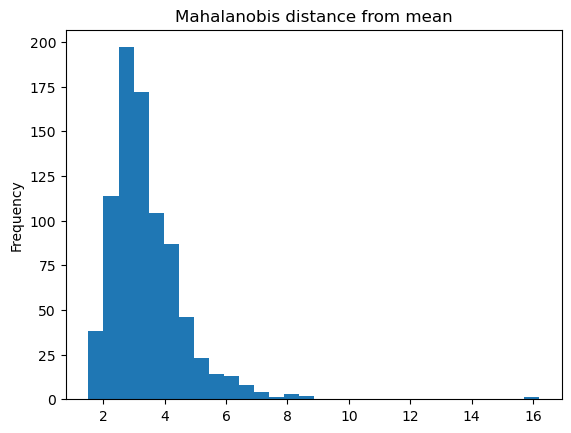

In [32]:
# Plot histogram of mahalanobis distances between each instance and variable mean
plt.hist(temp_mahalanobis_dists, bins=30)
plt.ylabel('Frequency')
plt.title('Mahalanobis distance from mean')
plt.show()

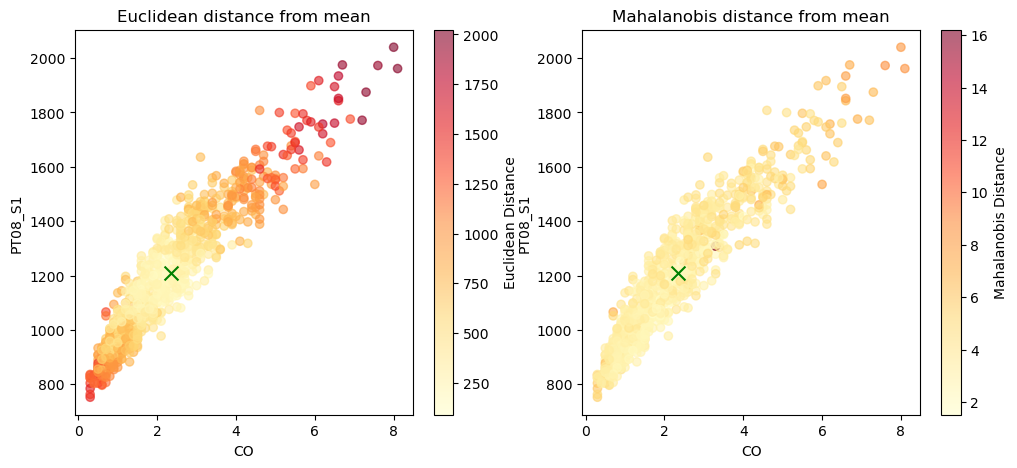

In [33]:
# Plot scatter plot to visualize values of mahalanobis and euclidean distances
# X-axis = First variable   # Can change to another variable
# Y-axis = Second variable  # Can change to another variable
# Green mark = mean

var1 = 'CO'
var2 = 'PT08_S1'
var1_index = 0
var2_index = 1

dist1 = 'Euclidean'
dist2 = 'Mahalanobis'

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
scatter1 = axs[0].scatter(temp_df.iloc[:, var1_index], temp_df.iloc[:, var2_index], c=temp_euclidean_dists, cmap='YlOrRd', alpha=0.6)
axs[0].scatter(temp_df_mu.iloc[var1_index], temp_df_mu.iloc[var2_index], c='green', marker='x', s=100)
axs[0].set_xlabel(var1)
axs[0].set_ylabel(var2)
axs[0].set_title(dist1 + ' distance from mean')
cbar = fig.colorbar(scatter1, ax=axs[0])
cbar.set_label('Euclidean Distance')

scatter2 = axs[1].scatter(temp_df.iloc[:, var1_index], temp_df.iloc[:, var2_index], c=temp_mahalanobis_dists, cmap='YlOrRd', alpha=0.6)
axs[1].scatter(temp_df_mu.iloc[var1_index], temp_df_mu.iloc[var2_index], c='green', marker='x', s=100)
axs[1].set_xlabel(var1)
axs[1].set_ylabel(var2)
axs[1].set_title(dist2 + ' distance from mean')
cbar = fig.colorbar(scatter2, ax=axs[1])
cbar.set_label('Mahalanobis Distance')

plt.show()

/tmp/ipykernel_6065/2560234777.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(mean, cov, n) # generate samples from multivariate normal


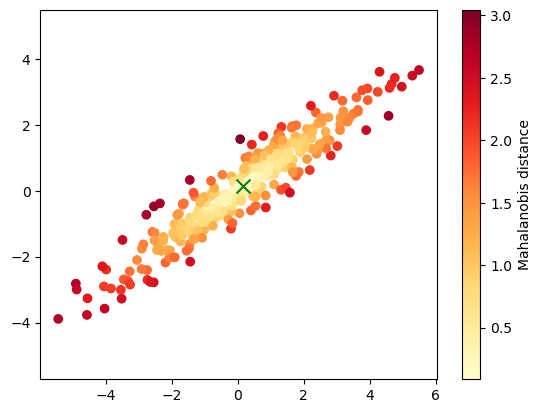

In [34]:
# Example to show that points close to mean can have large mahalanobis distance
#                      points far from mean can have small mahalanobis distance

np.random.seed(0)
n = 300
mean = [0, 0]
cov = [[4, 3],
       [3, 2]]  # correlated features
X = np.random.multivariate_normal(mean, cov, n) # generate samples from multivariate normal

# Compute mahalanobis distance from each instance and variable mean
VI = np.linalg.inv(np.cov(X.T))
mu = X.mean(axis=0)
dM = np.array([mahalanobis(x, mu, VI) for x in X])

plt.scatter(X[:,0], X[:,1], c=dM, cmap='YlOrRd')
plt.colorbar(label='Mahalanobis distance')
plt.scatter(mu[0], mu[1], color='green', marker='x', s=100, label='Mean')
plt.axis('equal')
plt.show()

# Mahalanobis distance scales deviations by the covariance
# small deviations along low-variance directions can yield large distances, 
# large deviations along high-variance directions can yield small distances.

5.876068326259565


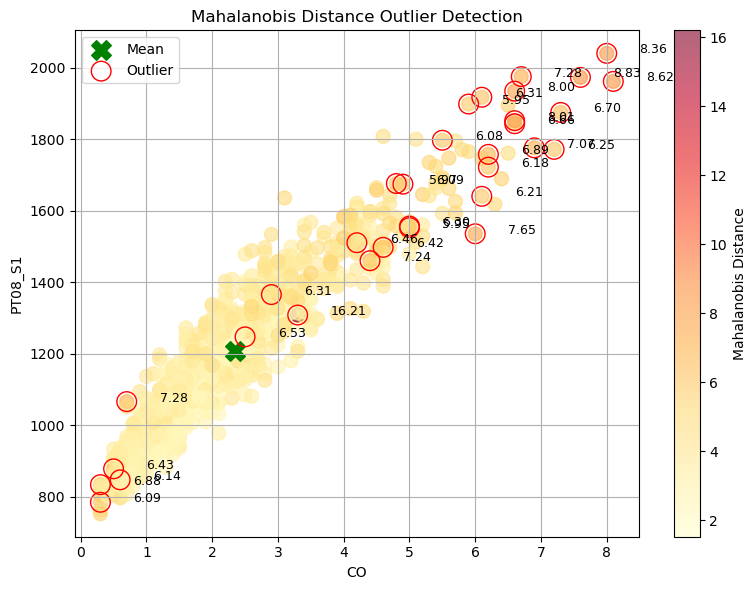

In [35]:
# Use mahalanobis distance to detect outliers

var1 = 'CO'
var2 = 'PT08_S1'
var1_index = 0
var2_index =1

temp_df = num_df.copy()
temp_df_cov = np.cov(temp_df.T)
VI = np.linalg.inv(temp_df_cov)

num_rows = len(num_df)
temp_df_mu = temp_df.mean(axis=0)  # variable mean
temp_euclidean_dists = [euclidean(temp_df.iloc[i], temp_df_mu) for i in range(0, num_rows)]
temp_mahalanobis_dists = [mahalanobis(temp_df.iloc[i], temp_df_mu, VI) for i in range(0, num_rows)]

# Define threshold
# Threshold can also be set based on chi-square distribution with degrees of freedom = #variables
from scipy.stats import chi2
threshold = np.sqrt(chi2.ppf(0.999, temp_df.shape[1]))  # dof=temp_df.shape[1], 99.9% cutoff
print(threshold)

# Find outliers
outliers = np.array(temp_mahalanobis_dists) > threshold
outliers_indices = [i for i, val in enumerate(outliers) if val]

# Plot scatter plot to show (var1, var2) values with color = mahalanobis distance
plt.figure(figsize=(8, 6))
scatter = plt.scatter(temp_df.iloc[:, var1_index], temp_df.iloc[:, var2_index], c=temp_mahalanobis_dists, cmap='YlOrRd', s=100, alpha=0.6)

# Plot the mean point of (var1, var2)
plt.scatter(temp_df_mu.iloc[var1_index], temp_df_mu.iloc[var2_index], color='green', marker='X', s=200, label='Mean')

# Plot outliers with red circles
plt.scatter(temp_df.iloc[outliers, var1_index], temp_df.iloc[outliers, var2_index], facecolors='none', edgecolors='red', s=200, label='Outlier')

# Annotate outliers with mahalanobis distance
for i, d in enumerate(outliers_indices):
    temp_dist = temp_mahalanobis_dists[d]
    plt.text(temp_df.iloc[d, var1_index] + 0.5, temp_df.iloc[d, var2_index], f'{temp_dist:.2f}', fontsize=9)

# Plot settings
plt.title('Mahalanobis Distance Outlier Detection')
plt.xlabel(var1)
plt.ylabel(var2)
plt.colorbar(scatter, label='Mahalanobis Distance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Curse of Dimensionality

[np.float64(1.7839451371720572), np.float64(3.0657485738456836), np.float64(4.217679139449918), np.float64(9.971163580953037), np.float64(14.060348717135566)]
[np.float64(0.9054972899512851), np.float64(0.9554070562667073), np.float64(0.9887988332081186), np.float64(0.8569702803508936), np.float64(0.9952030641062559)]


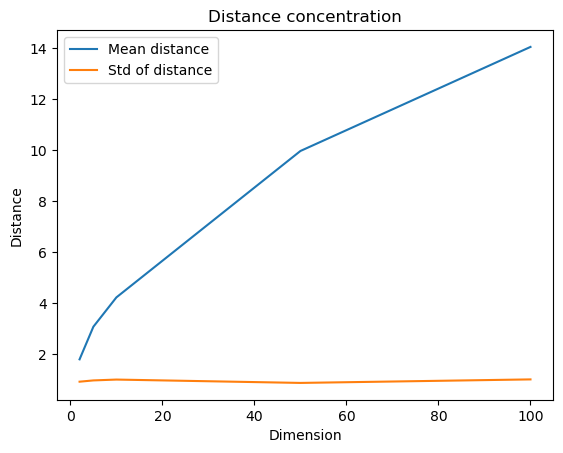

In [36]:
def euclidean_distance_stats(dim=2,n_samples=500):
    num_rows = 100
    X = np.random.randn(n_samples, dim)  # generate samples from standard normal 
    dists = [euclidean(X[i], X[i+1]) for i in range(0,num_rows+1)]
    return np.mean(dists), np.std(dists), dists

dims = [2, 5, 10, 50, 100]
dists = []
means = []
stds = []
for d in dims:
    temp_mean, temp_sd, temp_dists = euclidean_distance_stats(d)
    means.append(temp_mean)
    stds.append(temp_sd)
    dists.append(temp_dists)
print(means)
print(stds)

plt.plot(dims, means, label="Mean distance")
plt.plot(dims, stds, label="Std of distance")
plt.legend()
plt.xlabel("Dimension")
plt.ylabel("Distance")
plt.title("Distance concentration")
plt.show()

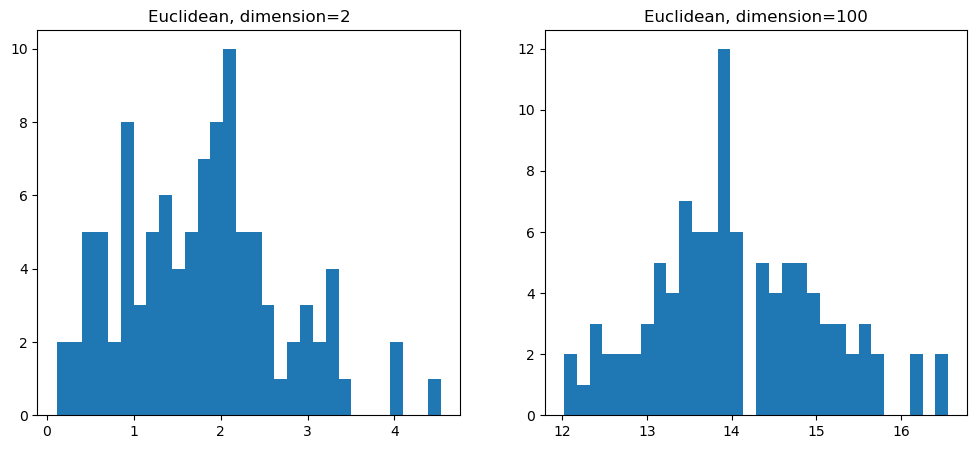

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(dists[0], bins=30)
axs[0].set_title('Euclidean, dimension=' + str(dims[0]))

max_dim = dims[len(dims)-1]
axs[1].hist(dists[len(dims)-1], bins=30)
axs[1].set_title('Euclidean, dimension=' + str(max_dim))
plt.show()

In [38]:
# Question: (A) When dimension is high, the lowest distance is close to zero or not?
#           (B) From (1) the line graph: distance centration above and (2) two histograms of distances at dimension = 2 and 100,
#           what can you conclude from these 3 graphs? 
# Answer and provide reason: (A) The lowest distance is not close to zero. It close to 12.
#                            (B) Data becomes sparse and distance concept is no longer true. (d_max - d_min)/d_min -\-> 0
#                                By adding dimensions, geometrically, distances lose meaning and noise dominates.

### PCA

In [39]:
# Find out PCs manually

temp_df = num_df.copy()

###############################################
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)
###############################################

# Covariance matrix
temp_df_cov = np.cov(temp_df_scaled, rowvar=False)

# Eigen-decomposition of covaraince matrix
eigenvalues, eigenvectors = np.linalg.eigh(temp_df_cov)
print(eigenvalues)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# Select first k eigenvectors
k = 2
V_d = eigenvectors[:, :k]

# Projection original data to PC space
temp_df_pca_manual =  temp_df_scaled  @ V_d   # @: matrix multiplication
temp_df_pca_manual

[3.12419418e-03 8.21628765e-03 1.61981866e-02 2.44109517e-02
 3.70925370e-02 6.10890683e-02 9.17649780e-02 1.35919737e-01
 1.98102098e-01 3.29531961e-01 9.37693156e-01 1.87715050e+00
 9.29544484e+00]


array([[-0.54011663, -0.13741422],
       [ 0.91873257,  0.06333546],
       [ 0.41778369, -0.46741865],
       ...,
       [-2.23102462, -2.00851607],
       [-2.1584592 , -1.99488193],
       [-2.87751698, -2.10758376]], shape=(827, 2))

In [40]:
# Find out PCs using PCA function from scikit-learn

temp_df = num_df.copy()

###############################################
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)
###############################################

# Call PCA function to find PCs
k = 2
from sklearn.decomposition import PCA
pca = PCA(n_components=k)
temp_df_pca = pca.fit_transform(temp_df_scaled)
temp_df_pca   
# note that np.linalg.eigh vs. sklearn’s PCA may choose different sign.  
# if v is an eigenvector, so is -v 
# projection may flip sign, but the orientation and variance of data cloud along that axis is exactly the same

array([[ 0.54011663,  0.13741422],
       [-0.91873257, -0.06333546],
       [-0.41778369,  0.46741865],
       ...,
       [ 2.23102462,  2.00851607],
       [ 2.1584592 ,  1.99488193],
       [ 2.87751698,  2.10758376]], shape=(827, 2))

In [41]:
print("Cov before PCA:\n", np.cov(temp_df_scaled.T))
print("\nCov after PCA:\n", np.cov(temp_df_pca.T))

Cov before PCA:
 [[ 1.00121065  0.93739099  0.88824155  0.97384972  0.95960415  0.95249341
  -0.82470648  0.86247484  0.94106009  0.884011    0.31885326 -0.10532197
   0.29594671]
 [ 0.93739099  1.00121065  0.78270413  0.93253133  0.93749712  0.92401108
  -0.83055616  0.86762288  0.94614959  0.93613586  0.32532999 -0.03963956
   0.407511  ]
 [ 0.88824155  0.78270413  1.00121065  0.89905773  0.87611507  0.81216403
  -0.7751447   0.72893329  0.84952614  0.7628312   0.36752573 -0.16050253
   0.28247827]
 [ 0.97384972  0.93253133  0.89905773  1.00121065  0.98598755  0.92845736
  -0.84973711  0.84776477  0.96201445  0.89807765  0.41877266 -0.17829744
   0.31398523]
 [ 0.95960415  0.93749712  0.87611507  0.98598755  1.00121065  0.92776515
  -0.91172411  0.88609804  0.95904187  0.91020981  0.44626323 -0.19358884
   0.32567734]
 [ 0.95249341  0.92401108  0.81216403  0.92845736  0.92776515  1.00121065
  -0.81527382  0.85846305  0.9138225   0.89446013  0.23878824 -0.04207117
   0.27100369]
 [-0.

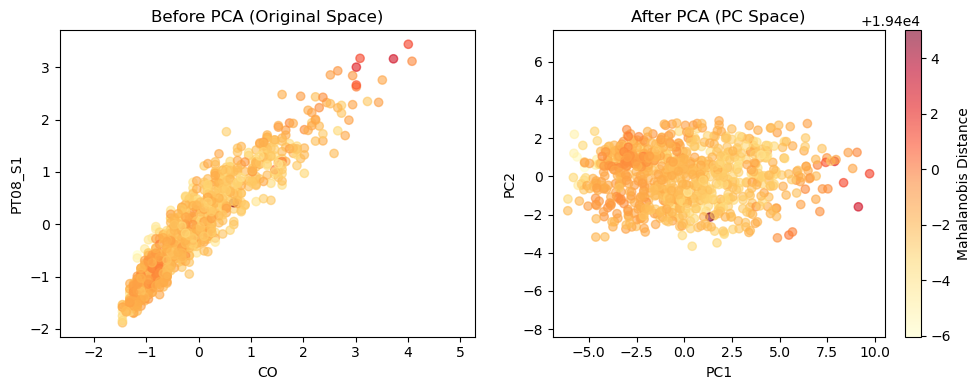

In [42]:
# Plot (var1,var2) with color = mahalanobis distance using left figure: X=var1, Y = var2
#                                                    right figure: X=PC1, Y=PC2

var1 = 'CO'
var2 = 'PT08_S1'
var1_index = 0
var2_index = 1

temp_df = num_df.copy()

################################################
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_df_scaled = scaler.fit_transform(temp_df)
################################################

###############################################
# Find mahalanobis distances between each instance and variable mean
temp_df_cov = np.cov(temp_df_scaled.T)
VI = np.linalg.inv(temp_df_cov)
num_rows = len(temp_df)
temp_df_mu = temp_df.mean(axis=0)
temp_mahalanobis_dists = np.array([mahalanobis(temp_df_scaled[i], temp_df_mu, VI) for i in range(0, num_rows)])
###############################################

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Left figure: X=var1, Y = var2
axs[0].scatter(temp_df_scaled[:, var1_index], temp_df_scaled[:, var2_index], c=temp_mahalanobis_dists, cmap='YlOrRd', alpha=0.6)
axs[0].set_title("Before PCA (Original Space)")
axs[0].set_xlabel(var1)
axs[0].set_ylabel(var2)
axs[0].axis("equal")

# Left figure: X=PC1, Y = PC2
scatter2 = axs[1].scatter(temp_df_pca[:, var1_index], temp_df_pca[:, var2_index], c=temp_mahalanobis_dists, cmap='YlOrRd', alpha=0.6)
axs[1].set_title("After PCA (PC Space)")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")
axs[1].axis("equal")
cbar = fig.colorbar(scatter2, ax=axs[1])
cbar.set_label('Mahalanobis Distance')

plt.tight_layout()
plt.show()